In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Functional_Fusion.dataset import DataSetHcpTask, DataSetMDTB
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import os
import random


Default device set to: cuda


In [2]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# HCP realibility

In [3]:
HCP_dataset = DataSetHcpTask('Y:/data/FunctionalFusion/HCP_tfMRI')
if not os.path.exists('Y:/data/FunctionalFusion/HCP_tfMRI'):
    HCP_dataset = DataSetHcpTask('/cifs/diedrichsen/data/FunctionalFusion/HCP_tfMRI')

data_hcp , info_hcp= HCP_dataset.get_data(space=space,ses_id='ses-task',type = 'CondHalf')


In [4]:
cov_matrices = [data @ data.T for data in data_hcp] 


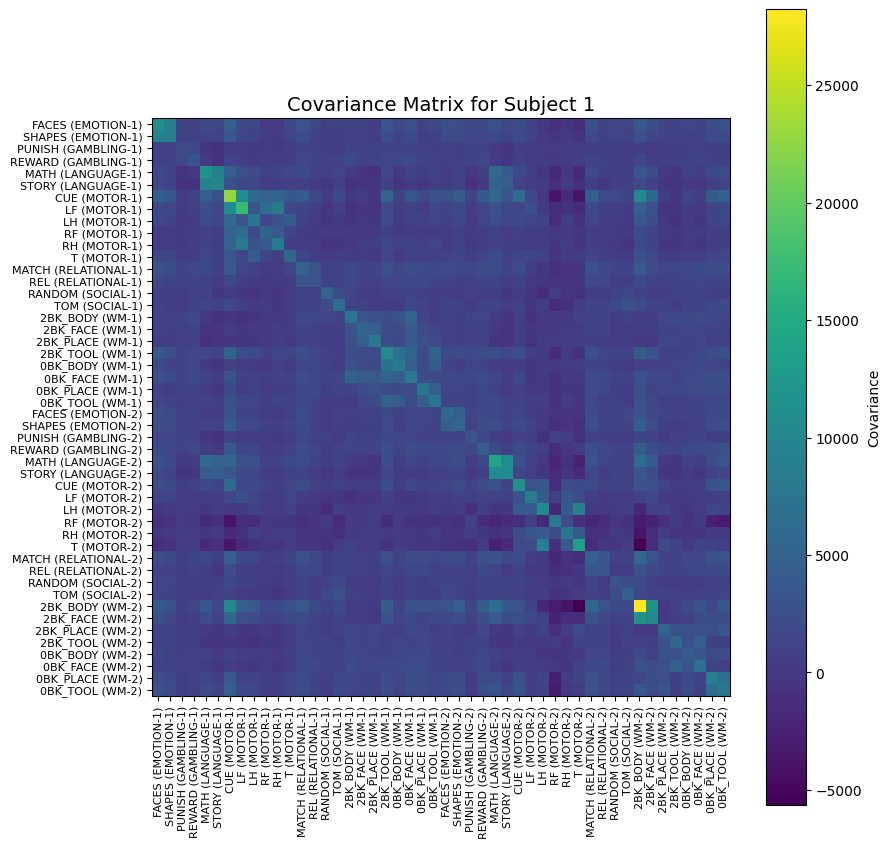

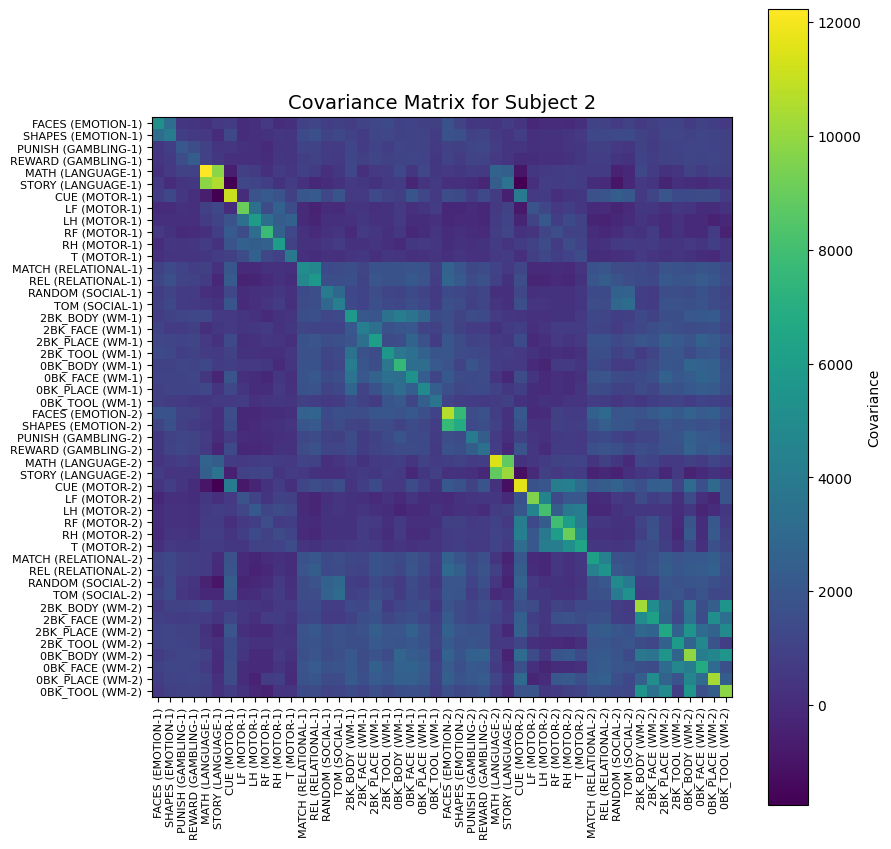

In [5]:
for i, cov in enumerate(cov_matrices):
    plt.figure(figsize=(9, 9))
    plt.imshow(cov, cmap='viridis', interpolation='nearest')
    
    
    labels = info_hcp["cond_name"] + " (" + info_hcp["task_name"] + "-" + info_hcp["half"].astype(str) + ")"
    tick_positions = np.arange(len(labels))
    
    plt.xticks(tick_positions, labels, rotation=90, fontsize=8)
    plt.yticks(tick_positions, labels, fontsize=8)
    
    plt.title(f"Covariance Matrix for Subject {i+1}", fontsize=14)
    plt.colorbar(label="Covariance")
    plt.tight_layout()
    plt.show()

In [6]:
half1_indices = info_hcp[info_hcp["half"] == 1].index
half2_indices = info_hcp[info_hcp["half"] == 2].index

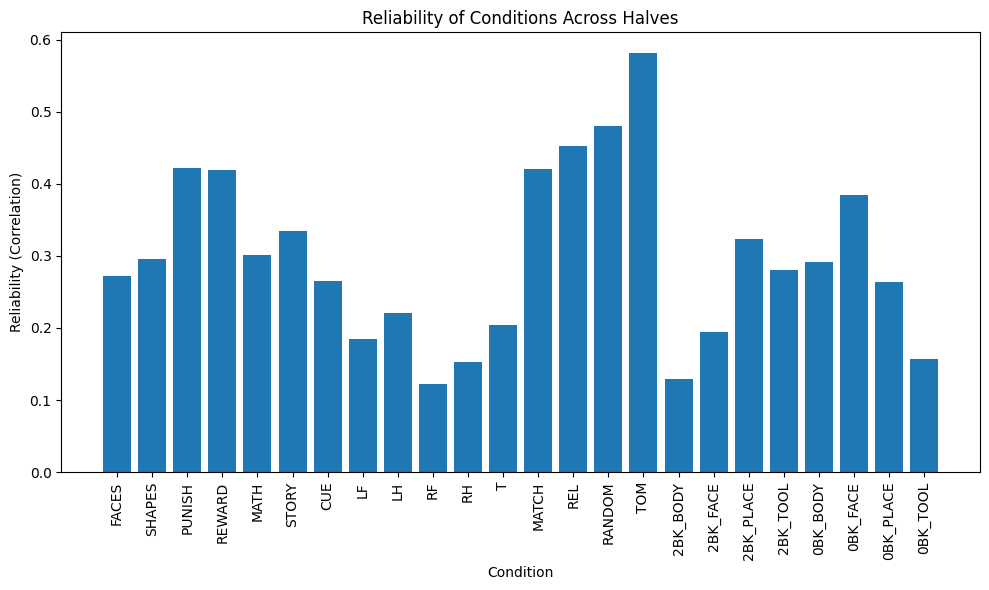

In [7]:
correlations = []
for i in range(len(half1_indices)):
    condition_half1 = data_hcp[:, half1_indices[i], :]  
    condition_half2 = data_hcp[:, half2_indices[i], :]

    subject_correlations = []
    for s in range(data_hcp.shape[0]):
        subject_correlations.append(np.corrcoef(condition_half1[s], condition_half2[s])[0, 1])

    
    avg_correlation = np.mean(subject_correlations)
    correlations.append(avg_correlation)

info_hcp["reliability"] = np.nan
info_hcp.loc[half1_indices, "reliability"] = correlations


plt.figure(figsize=(10, 6))
plt.bar(range(len(correlations)), correlations)
plt.xticks(range(len(correlations)), info_hcp.loc[half1_indices, "cond_name"], rotation=90)
plt.xlabel("Condition")
plt.ylabel("Reliability (Correlation)")
plt.title("Reliability of Conditions Across Halves")
plt.tight_layout()
plt.show()

# MDTB realibility

In [8]:
MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
if not os.path.exists('Y:/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')

data_mdtb, mdtb_info = MDTB_dataset.get_data(space=space, ses_id='ses-s1', type='CondRun')


Blocked design

In [9]:
def contrast_rest(data, info, tasks, rest_condition, runs):
    averaged_contrasts = []
    for task in tasks:
        task_contrasts = []
        for run in runs:
            run_info = info[info['run'] == run]
            task_idx = run_info[run_info['cond_name'] == task].index[0]
            rest_idx = run_info[run_info['cond_name'] == rest_condition].index[0]
            task_contrasts.append(data[:, task_idx, :] - data[:, rest_idx, :])
        averaged_contrasts.append(np.mean(task_contrasts, axis=0))
    return np.stack(averaged_contrasts, axis=1)

In [10]:
tasks = ["ToM", "MotorImagery"]
rest_condition = "rest"
runs = range(1, 5)

contrasts_run_1_half_1 = contrast_rest(data_mdtb, mdtb_info, tasks, rest_condition, runs)
contrasts_run_1_half_1.shape

(24, 2, 59518)

In [11]:
tasks = ['SpatialNavigation','FingerSeq']
rest_condition = 'rest'
runs = range(5, 9)

contrasts_run_2_half_1 = contrast_rest(data_mdtb, mdtb_info, tasks, rest_condition, runs)
contrasts_run_2_half_1.shape

(24, 2, 59518)

In [12]:
# concatenate the two runs
blocked_data_half_1 = np.concatenate([contrasts_run_1_half_1, contrasts_run_2_half_1], axis=1)
blocked_data_half_1.shape

(24, 4, 59518)

In [13]:
tasks = ["ToM", "MotorImagery"]
rest_condition = "rest"
runs = range(9, 13)

contrasts_run_1_half_2 = contrast_rest(data_mdtb, mdtb_info, tasks, rest_condition, runs)
contrasts_run_1_half_2.shape

(24, 2, 59518)

In [14]:
tasks = ['SpatialNavigation','FingerSeq']
rest_condition = 'rest'
runs = range(13, 17)

contrasts_run_2_half_2 = contrast_rest(data_mdtb, mdtb_info, tasks, rest_condition, runs)
contrasts_run_2_half_2.shape

(24, 2, 59518)

In [15]:
blocked_data_half_2 = np.concatenate([contrasts_run_1_half_2, contrasts_run_2_half_2], axis=1)
blocked_data_half_2.shape

(24, 4, 59518)

Interspersed design

In [16]:
def contrast_mean(data, info, tasks, runs):
    averaged_contrasts = []
    for task in tasks:
        task_contrasts = []
        for run in runs:
            run_info = info[info['run'] == run]
            task_idx = run_info[run_info['cond_name'] == task].index[0]
            all_task_indices = run_info[run_info['cond_name'].isin(tasks)].index.tolist()
            mean_all_tasks = np.mean(data[:, all_task_indices, :], axis=1)
            task_contrasts.append(data[:, task_idx, :] - mean_all_tasks)
        averaged_contrasts.append(np.mean(task_contrasts, axis=0))
    return np.stack(averaged_contrasts, axis=1)




In [17]:
conditions = ["ToM", "MotorImagery", "SpatialNavigation", "FingerSeq"]
runs = range(1, 5)
interspersed_data_half_1 = contrast_mean(data_mdtb, mdtb_info, conditions, runs)
interspersed_data_half_1.shape

(24, 4, 59518)

In [18]:
conditions = ["ToM", "MotorImagery", "SpatialNavigation", "FingerSeq"]
runs = range(5, 9)
interspersed_data_half_2 = contrast_mean(data_mdtb, mdtb_info, conditions, runs)
interspersed_data_half_2.shape


(24, 4, 59518)

In [19]:
# Nans to zeros
interspersed_data_half_1[np.isnan(interspersed_data_half_1)] = 0
interspersed_data_half_2[np.isnan(interspersed_data_half_2)] = 0
blocked_data_half_1[np.isnan(blocked_data_half_1)] = 0
blocked_data_half_2[np.isnan(blocked_data_half_2)] = 0


In [20]:
def compute_reliability(data_half_1, data_half_2):
    """
    Computes reliability (correlation) between two halves of the data for each subject.
    """
    num_subjects = data_half_1.shape[0]
    num_contrasts = data_half_1.shape[1]
    correlations = []

    for s in range(num_subjects):
        subject_corr = []
        for c in range(num_contrasts):
            contrast_half_1 = data_half_1[s, c, :]
            contrast_half_2 = data_half_2[s, c, :]

            # Correlate
            corr = np.corrcoef(contrast_half_1, contrast_half_2)[0, 1]
            subject_corr.append(corr)

        # storing  each subject's average correlation across contrasts
        correlations.append(np.mean(subject_corr))

    return np.array(correlations)

reliability_blocked = compute_reliability(blocked_data_half_1, blocked_data_half_2)
reliability_interspersed = compute_reliability(interspersed_data_half_1, interspersed_data_half_2)




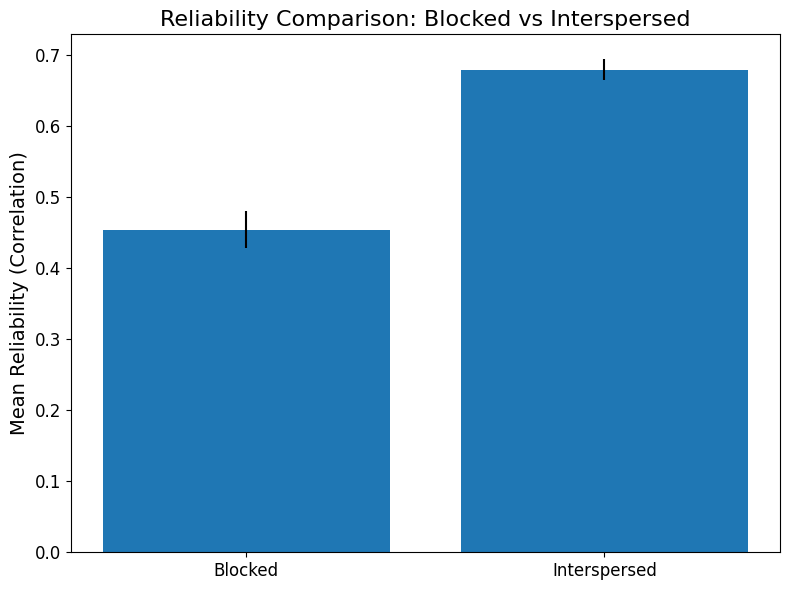

In [22]:
mean_reliability = [
    np.mean(reliability_blocked),
    np.mean(reliability_interspersed)
]
sem_reliability = [
    np.std(reliability_blocked) / np.sqrt(len(reliability_blocked)),
    np.std(reliability_interspersed) / np.sqrt(len(reliability_interspersed))
]

design_labels = ['Blocked', 'Interspersed']
plt.figure(figsize=(8, 6))
plt.bar(design_labels, mean_reliability, yerr=sem_reliability)
plt.ylabel('Mean Reliability (Correlation)', fontsize=14)
plt.title('Reliability Comparison: Blocked vs Interspersed', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(reliability_blocked, reliability_interspersed)
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_val}")


t-statistic: -11.178444734079289
p-value: 8.978202382207893e-11
